In [1]:
import algorithms.SCoNE as SCoNE
import algorithms.MVBCWrapper as MVBCWrapper
import algorithms.RGWASWrapper as RGWASWrapper
import importlib
importlib.reload(SCoNE)
import pandas as pd
import evaluation.cluster_evaluation as cluster_evaluation
from itertools import product
import submitit
import os

colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

# Code to simulate data

In [2]:
import numpy as np

def proj_nonneg(x):
    # If already feasible, return x as-is (avoids an allocation most iterations)
    if x.min() >= 0:
        return x
    return np.maximum(x, 0)

def make_correlated_matrices(m, r, rho, seed=1):
    rng = np.random.default_rng(seed)
    Z = proj_nonneg(rng.normal(size=(m, r)))
    E = proj_nonneg(rng.normal(size=(m, r)))
    W1 = Z
    W2 = rho * Z + np.sqrt(1 - rho**2) * E
    if rho==1:
        assert np.allclose(W1, W2)
    return W1, W2

def simulate_views(n=2500, num_genes=100, M_C=100, M_Z=5, rank=3, seed=0, ZU_weight=1, noise=0, sparsity=0, rho=1):
    """
    G:  n x num_genes  (Poisson with rate WH_g.T + ZU_g.T)
    C:  n x M_C  (Poisson with rate WH_c.T + ZU_c.T)

    Z: n x M_Z covariates (non-negative random numbers)

      W   : n x rank
      H_g : num_genes x rank
      U_g : M_Z x num_genes
      H_c: n x M_C
      U_c: M_Z x M_C
    """
    rng = np.random.default_rng(seed)

    # 1. Sample factor matrices
    # Sample nonnegative factors so Poisson rates are valid
    W_C, W_G = make_correlated_matrices(n, rank, rho,seed=seed+1)
    H_C = proj_nonneg(rng.normal(size=(M_C, rank)))
    # generate linked markers
    H_G = proj_nonneg(rng.normal(size=(num_genes, rank)))
    # generate superpop shift for each feature
    U_C = proj_nonneg(rng.normal(size=(M_C, M_Z)))
    U_G =  proj_nonneg(rng.normal(size=(num_genes, M_Z)))
    # generate 5 superpopulations
    superpops = rng.permutation(n) % M_Z   
    Z = (superpops[:, None] == np.arange(M_Z)).astype(int) 

    #2. impose sparsity (P(W_ij=0)=sparsity)
    mask = np.random.rand(*(n,rank)) > sparsity
    W_C = W_C * mask
    W_G = W_G * mask
    avg_corr = np.mean([np.corrcoef(W_C[:,k], W_G[:,k])[0,1]
                    for k in range(W_C.shape[1])])

    
    # Means
    M_c = W_C@H_C.T + (ZU_weight)*Z@U_C.T + (noise)*proj_nonneg(rng.normal(size=(n, M_C)))
    M_g = W_G@H_G.T + (ZU_weight)*Z@U_G.T + (noise)*proj_nonneg(rng.normal(size=(n, num_genes)))

    # Generate the two observed matrices
    G = rng.poisson(M_g)  
    C = rng.poisson(M_c)          

    return {"G": G, "C": C, "Z":Z, "W_C": W_C, "W_G":W_G, "H_G": H_G, "H_C": H_C, "U_G": U_G, "U_C": U_C}

sim = simulate_views(n=200,M_C=50,num_genes=50,M_Z=5,rank=3,seed=0,ZU_weight=1,noise=0,sparsity=0)

# Code to evaluate reconstruction

In [3]:
from scipy.optimize import linear_sum_assignment


def frobenius_cosine_similarity(A, B):
    num = np.trace(A.T @ B)
    den = np.sqrt(np.trace(A.T @ A)) * np.sqrt(np.trace(B.T @ B))
    return num / den

def best_permutation_similarity(W_true, W_hat):
    # Compute pairwise column inner products (the numerator terms)
    M = W_true.T @ W_hat 
    row_ind, col_ind = linear_sum_assignment(-M) # maximize numerator
    W_hat_perm = W_hat[:, col_ind] # optimal permutation
    return frobenius_cosine_similarity(W_true, W_hat_perm)


# Code to run all comparison methods (and parallelize)

In [4]:
# submit as a SLURM array (adjust params as needed)
root_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno'
os.makedirs(f"{root_dir}/output/slurm_logs", exist_ok=True)
tmp_folder = f"{root_dir}/output/tmp"
os.makedirs(tmp_folder, exist_ok=True)
executor = submitit.AutoExecutor(folder=f"{root_dir}/slurm_logs")
executor.update_parameters(
    slurm_job_name="fact-grid",
    timeout_min=60, # TODO: increase to 400 min
    cpus_per_task=1,
    mem_gb=3,
    slurm_array_parallelism=200,
    stderr_to_stdout=True,
    slurm_additional_parameters={
        "output": f"{root_dir}/output/slurm_logs/%x_%A_%a.out",
        "error":  f"{root_dir}/output/slurm_logs/%x_%A_%a.out",
        "export": "ALL,PYTHONUNBUFFERED=1",
        "mail-type": "FAIL",                      
        "mail-user": "anewbury@nygenome.org",
    },
)

In [40]:
def run_one_wrapper(run_name,G,C,Z,lambda_W,lambda_H_G,lambda_H_C,lambda_Gloss,G_loss_type,C_loss_type,
                    G_path,C_path,Z_path,sim,rank=3,init_name=1):
    results = []
    results_columns = ['run_name','factor_matrix','init','sim','total_loss']
    # simulate data
    if run_name in ['G-NMF','C-NMF','G-CoNE','C-CoNE','HNMF','CoNE','SCoNE','SCoNE(Fro)','sHNMF','CoNE(Fro)']:
        algorithm_func_kwargs={"G":G, "C":C, "Z":Z,"rank":rank, "num_init":1,
                        "lambda_W":lambda_W, "lambda_H_G":lambda_H_G, "lambda_H_C":lambda_H_C,"lambda_Gloss":lambda_Gloss,
                        "max_inner":50, "rho":0.1, "sigma":1e-4, "inner_ftol":1e-4,
                        "G_loss_type":G_loss_type, "C_loss_type": C_loss_type,
                        "max_outer":100, "min_outer":5, "tol":1e-6}
        factor_matrices, loss_function = SCoNE.alternating_opt(**algorithm_func_kwargs)
        total_loss = loss_function['total_loss'][-1]
    elif run_name == 'MVBC':
        algorithm_func_kwargs = {"G_path":G_path,"C_path":C_path, "rank":rank,
                    "lambda_W":lambda_W, "lambda_H_G":lambda_H_G, "lambda_H_C":lambda_H_C, "r_path":'/gpfs/commons/home/anewbury/miniconda/bin/Rscript'}
        factor_matrices, loss_function = MVBCWrapper.MVBCWrapper(**algorithm_func_kwargs)
        print(factor_matrices["W"].sum(axis=0))
        total_loss = loss_function['total_loss'][-1]
    elif run_name == 'RGWAS':
        algorithm_func_kwargs = {"r_path":'/gpfs/commons/home/anewbury/miniconda/bin/Rscript', "G_path":G_path,
                        "C_path":C_path, "Z_path":Z_path, "num_init":1,"rank":rank}
        factor_matrices, loss_function = RGWASWrapper.RGWASWrapper(**algorithm_func_kwargs)
    else: assert True == False, f"invalid run name {run_name}"
    for k,v in factor_matrices.items():
        if k=="W":
            results.append([run_name,"W_C",init_name,best_permutation_similarity(sim["W_C"],v),total_loss])
            results.append([run_name,"W_G",init_name,best_permutation_similarity(sim["W_G"],v),total_loss])
        else:
            results.append([run_name,k,init_name,best_permutation_similarity(sim[k],v),total_loss])
    results = pd.DataFrame(results,columns=results_columns)
    return results

In [18]:
from plotnine import *
def run_one(variable_name, variable_range):
    testing_runs = ['G-NMF','C-NMF','G-CoNE','C-CoNE','HNMF','CoNE','SCoNE','SCoNE(Fro)','RGWAS','MVBC']
    tuning_runs = ['SCoNE','SCoNE(Fro)','MVBC']
    for variable in variable_range:
        # SIMUALTE DATA 
        sim_kwargs = {"n":100,"M_C":10,"num_genes":10,variable_name:variable,"seed":0} # TODO: change back to larger, 200, 50, 50
        
        sim = simulate_views(**sim_kwargs) 
        # write G,C,Z to paths
        np.save(f'{tmp_folder}/G_{variable_name}_{variable}',sim["G"])
        np.save(f'{tmp_folder}/C_{variable_name}_{variable}',sim["C"])
        np.save(f'{tmp_folder}/Z_{variable_name}_{variable}',sim["Z"])
        # TUNING
        lambda_options = [0.01,0.1] # TODO: change to [1e-4,1e-3,1e-2,1,10,100,1000]
        lambda_combos = product(lambda_options,lambda_options,lambda_options)
        tuning_results = []
        for init in range(10):
            for lambda_W,lambda_H_G,lambda_H_C in lambda_combos:
                for run_name in tuning_runs:
                    print(f'init:{init},run name:{run_name},lambda_W:{lambda_W}, lambda_H_G: {lambda_H_G}, lambda_H_C: {lambda_H_C}')
                    results = run_one_wrapper(run_name,sim["G"] if not 'C-' in run_name else None,
                                    sim["C"] if not 'G-' in run_name else None,
                                    sim["Z"] if not 'NMF' in run_name else np.zeros((sim["Z"].shape[0],sim["Z"].shape[1])),
                                    lambda_W,lambda_H_G,lambda_H_C,lambda_Gloss=1,
                                    G_loss_type='kl_div' if not 'C-' in run_name else None,
                                    C_loss_type='kl_div' if not 'G-' in run_name else None,sim=sim,rank=3,init_name=init,
                                    G_path=f'{tmp_folder}/G_{variable_name}_{variable}.npy',
                                    C_path=f'{tmp_folder}/C_{variable_name}_{variable}.npy',
                                    Z_path=f'{tmp_folder}/Z_{variable_name}_{variable}.npy')
                    results[variable_name] = variable
                    tuning_results.append(results)
        tuning_results = pd.concat(tuning_results)
        print(tuning_results[tuning_results['total_loss']=='NaN'])
        idx = tuning_results.groupby(['run_name'])["total_loss"].idxmin()
        best = (
            tuning_results.loc[idx, tuning_results.columns]
            .reset_index(drop=True)
        )
        print(best)
    #     # testing set
    #     sim_kwargs = {"n":100,"M_C":10,"num_genes":10,variable_name:variable,"seed":1} # TODO: change back to larger, 200, 50, 50
    #     sim = simulate_views(**sim_kwargs) 
    #     inits = range(10)
    #         for init in range(10):
    #             run_one_wrapper(run_name,G,C,Z,lambda_W,lambda_H_G,lambda_H_C,lambda_Gloss,G_loss_type,C_loss_type,rank=3,init_name=1)
    #             factor_matrices, loss_function = SCoNE.alternating_opt(sim["G"] if not 'C-' in run_name else None,
    #                 sim["C"] if not 'G-' in run_name else None,
    #                 sim["Z"] if not 'NMF' in run_name else np.zeros((sim["Z"].shape[0],sim["Z"].shape[1])),rank=3,num_init=1,
    #                 lambda_W=0, lambda_H_G=0, lambda_H_C=0, lambda_Gloss=1,
    #                 max_inner=50, rho=0.1, sigma=1e-4, inner_ftol=1e-5,tol=1e-6,C_loss_type='kl_div' if not 'G-' in run_name else None,
    #                 G_loss_type='kl_div' if not 'C-' in run_name else None,  min_outer=5)
    #             for k,v in factor_matrices.items():
    #                 if k=="W":
    #                     results.append([run_name,"W_C",init,best_permutation_similarity(sim["W_C"],v),variable])
    #                     results.append([run_name,"W_G",init,best_permutation_similarity(sim["W_G"],v),variable])
    #                 else:
    #                     results.append([run_name,k,init,best_permutation_similarity(sim[k],v),variable])
    #     for run_name in ['SCoNE','SCoNE (Fro)', 'MVBC']:
    #         # hparam runing on different dataset
    #         lambda_options = [1e-4,1e-3,1e-2,1,10,100,1000]
    #         lambda_combos = product(lambda_options,lambda_options,lambda_options)
    #         cfgs = [
    #         dict(
    #             g_ps=g_ps, c_ps=c_ps, e=e, dataset=tuning_dataset[g_ps,c_ps, e],
    #             num_init = 10, 
    #             Z=Z if run_name != 'sHNMF' else np.zeros((Z.shape[0],Z.shape[1])), rank=rank,
    #             lambda_W=lambda_W, lambda_H_G=lambda_H_G, lambda_H_C=lambda_H_C,lambda_Gloss=1,
    #             max_outer=max_outer, min_outer=5, tol=1e-6,
    #             sim_output_dir=sim_output_dir, exp_num=exp_map[g_ps,c_ps, e],
    #             run_name=run_name,G_loss_type='kl_div' if run_name!='SCoNE(Fro)' else 'fro', C_loss_type='kl_div' if run_name!='SCoNE(Fro)' else 'fro',
    #             artifact_dir=f"{os.path.dirname(artifact_dir)}/logs_tuning"
    #         )
    #         for i, (g_ps,c_ps, e, lambda_W, lambda_H_G, lambda_H_C, run_name) in enumerate(combos)
    #     ]
    #     jobs = executor.map_array(_call_kwargs, cfgs)
    #     for run_name in ['RGWAS']:
    #         # run
    # df = pd.DataFrame(results,columns=results_columns)
    # summary = (
    #     df.groupby(["run_name", "factor_matrix", 'variable'])["sim"]
    #         .agg(n='count', mean='mean', std='std').reset_index()
    # )
    # summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])         # normal approx 95% CI
    # summary["ymin"] = summary["mean"] - summary["ci95"]
    # summary["ymax"] = summary["mean"] + summary["ci95"]

    # return summary

# Assess runs over correlation
noise=0, sparsity=0, weight=0.5

In [35]:
import importlib
importlib.reload(MVBCWrapper)

<module 'algorithms.MVBCWrapper' from '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/code/algorithms/MVBCWrapper.py'>

In [41]:
run_one("rho", [0.1])


init:0,run name:SCoNE,lambda_W:0.01, lambda_H_G: 0.01, lambda_H_C: 0.01
init:0,run name:SCoNE(Fro),lambda_W:0.01, lambda_H_G: 0.01, lambda_H_C: 0.01
init:0,run name:MVBC,lambda_W:0.01, lambda_H_G: 0.01, lambda_H_C: 0.01
[1] 2739.887
{"factor_matrices":{"W":[[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[0,1,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0],[1,0,0

KeyboardInterrupt: 

In [56]:
summary = run_one("rho", np.arange(0,1.1,0.1))


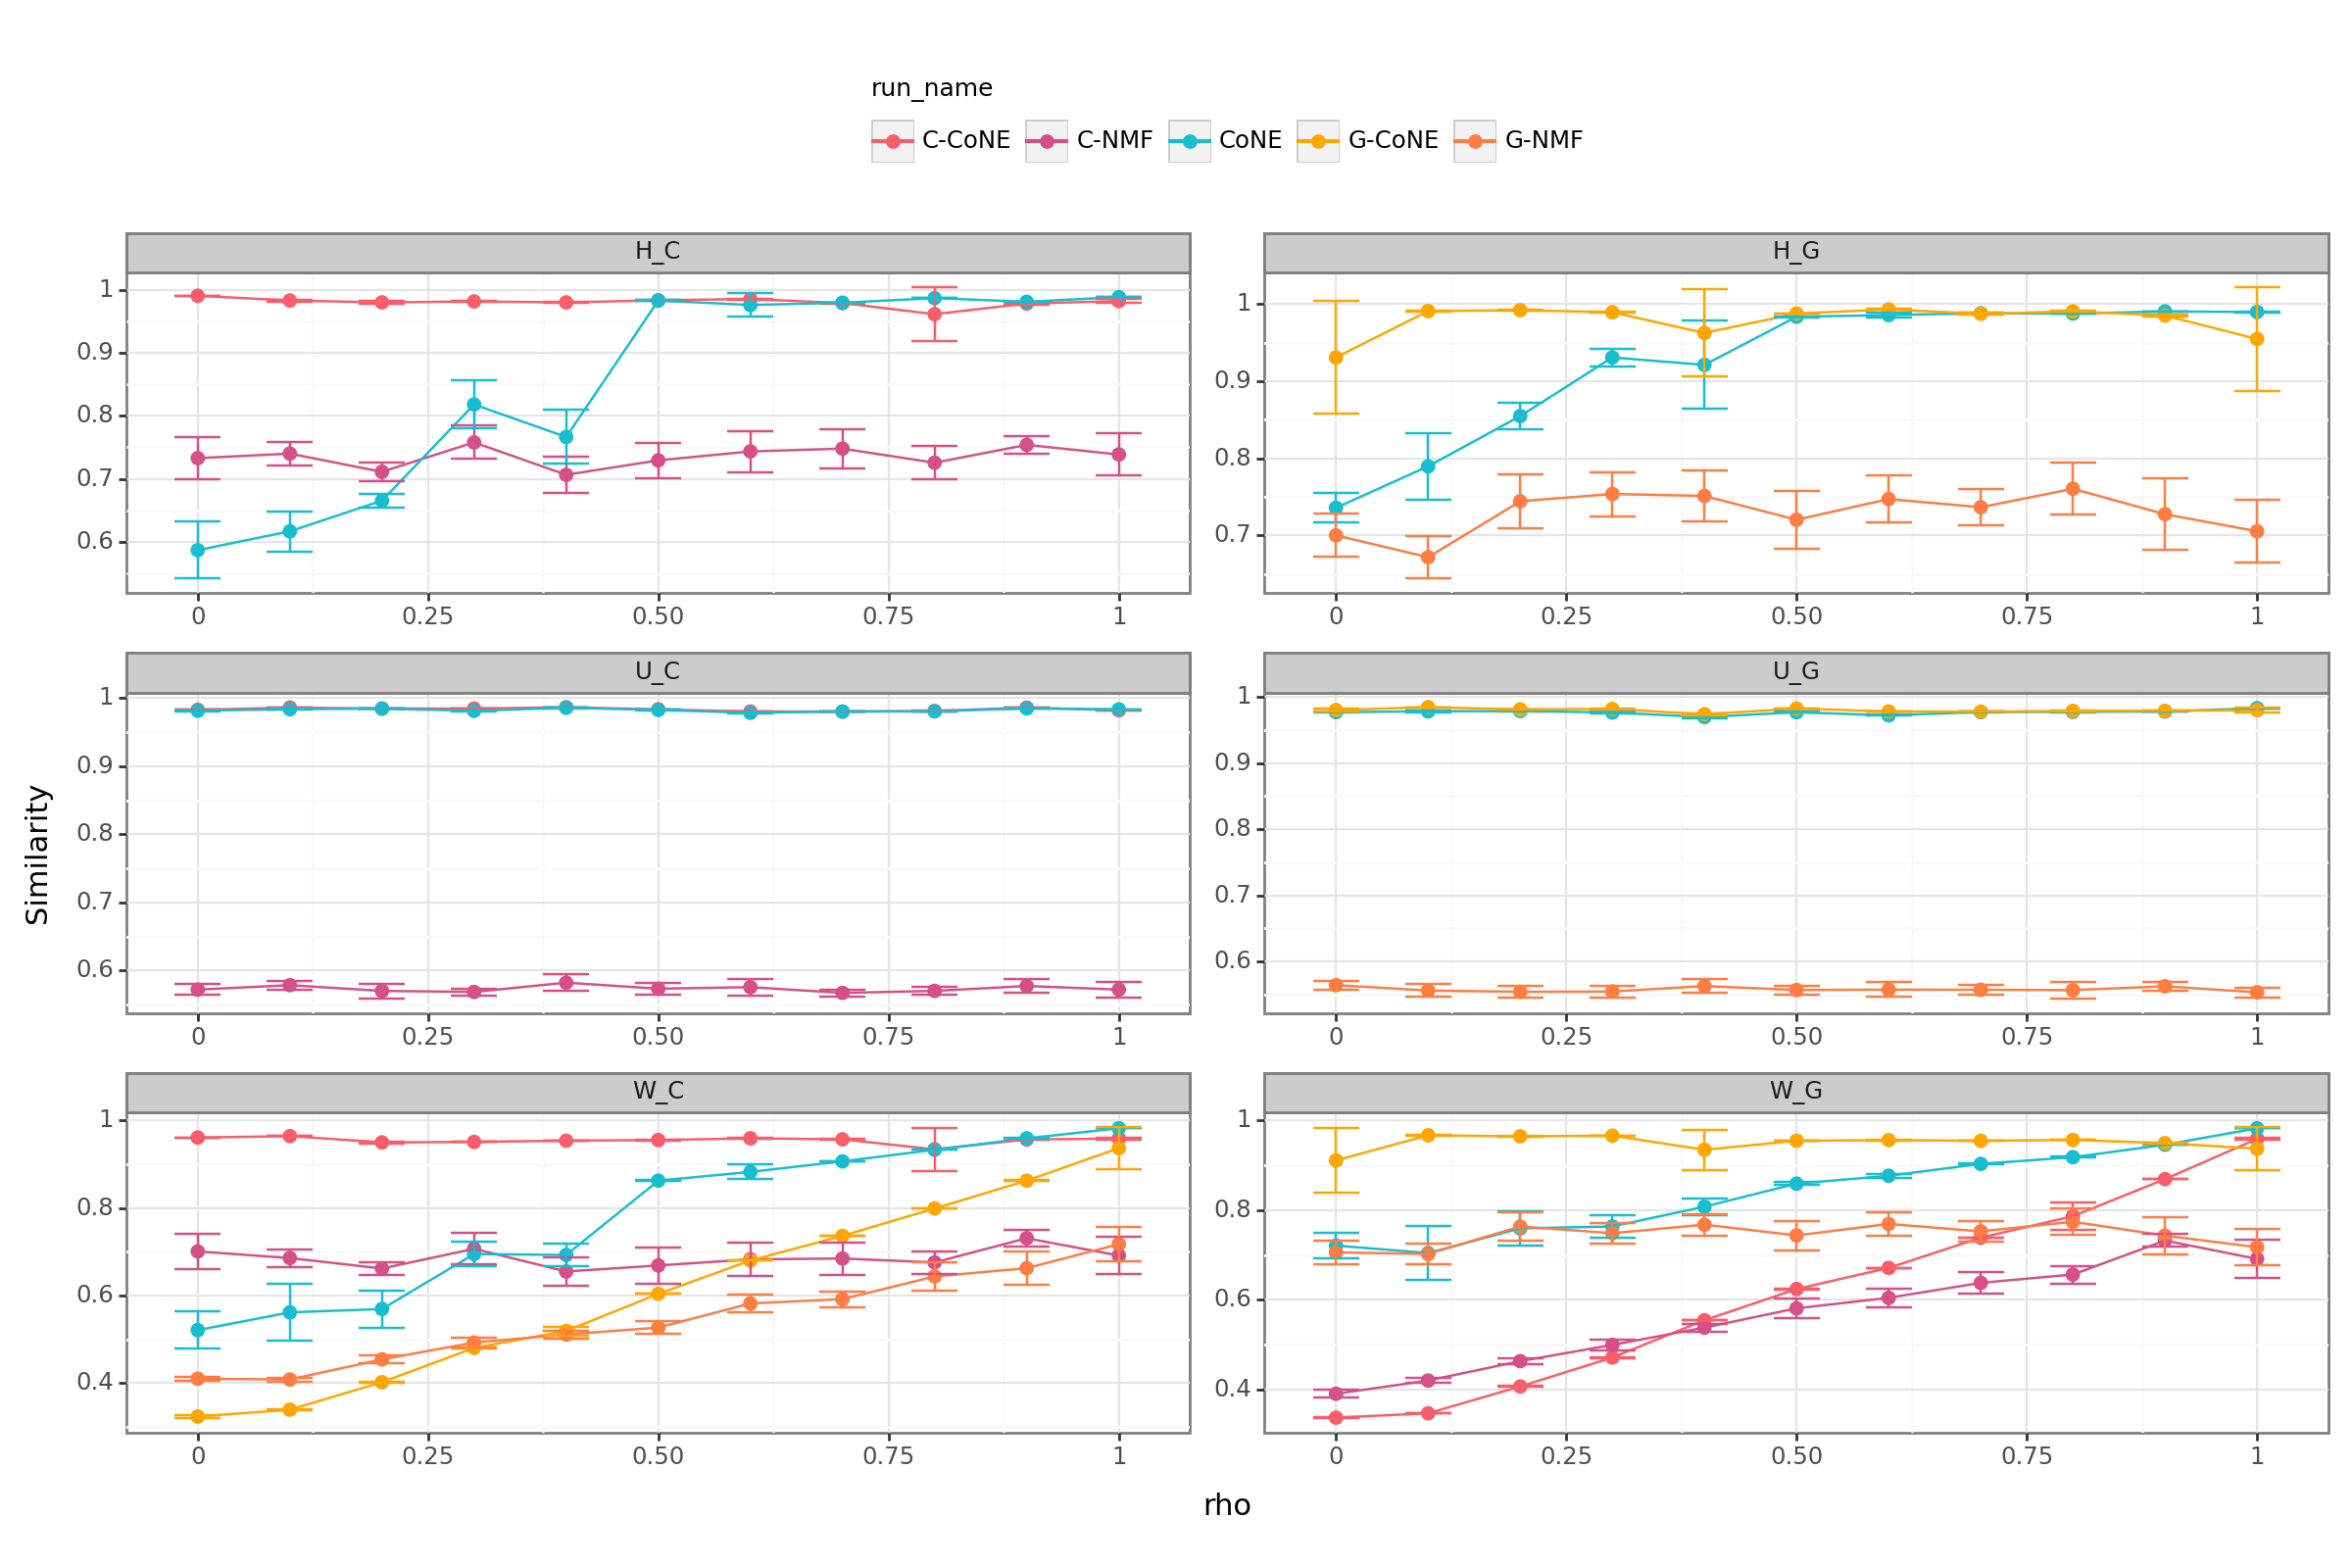

In [57]:
dodge = position_dodge(width=0.15)
p = (
    ggplot(summary[summary['run_name'].isin(['C-CoNE','C-NMF','G-NMF','G-CoNE','CoNE'])], aes("variable", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3,scales='free')
    + labs(y='Similarity',x="rho")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

# Assess runs over ZU weight

In [58]:
summary = run_one("ZU_weight", [0,0.25,0.5,0.75,1,1.5,2])


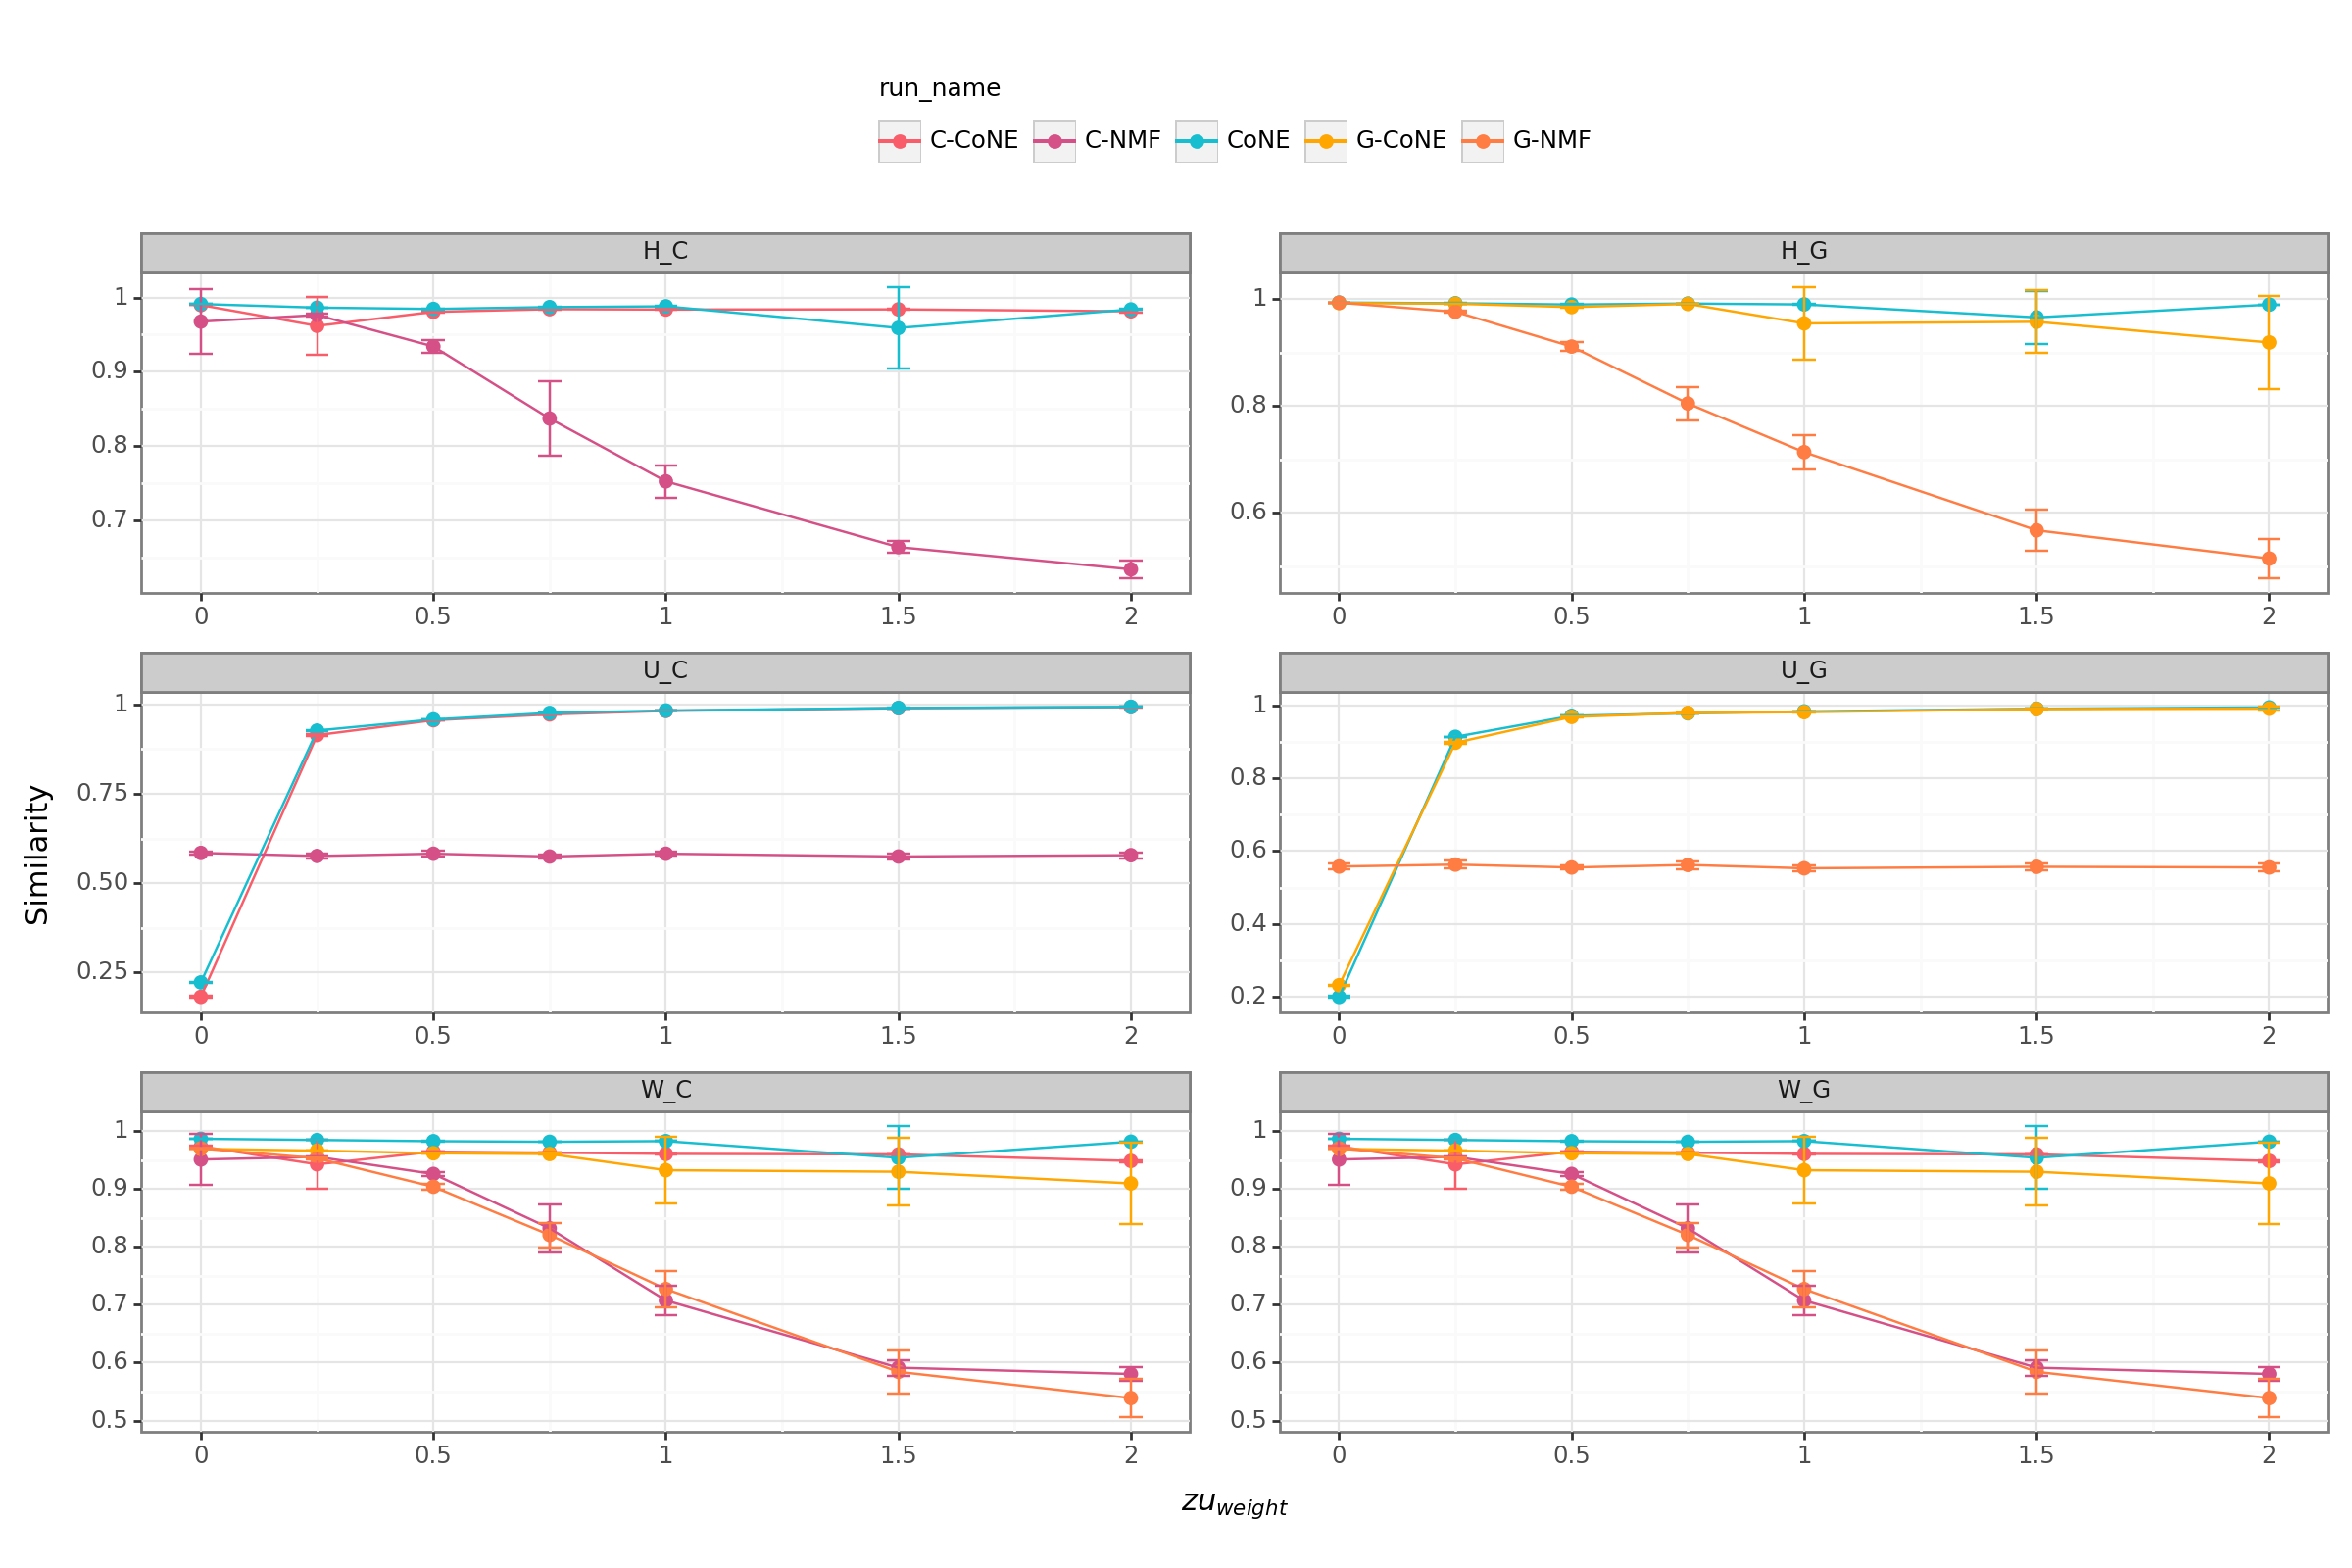

In [59]:
dodge = position_dodge(width=0.15)
p = (
    ggplot(summary[summary['run_name'].isin(['C-CoNE','C-NMF','G-NMF','G-CoNE','CoNE'])], aes("variable", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3,scales='free')
    + labs(y='Similarity',x=r"$zu_{weight}$")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

# Assess runs over noise

In [ ]:
summary = run_one("noise",  np.arange(0,1.1,0.1))


In [ ]:
dodge = position_dodge(width=0.15)
p = (
    ggplot(summary[summary['run_name'].isin(['C-CoNE','C-NMF','G-NMF','G-CoNE','CoNE'])], aes("variable", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3,scales='free')
    + labs(y='Similarity',x=r"$zu_{weight}$")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

# Assess runs over sparsity

In [ ]:
summary = run_one("sparsity",  np.arange(0,1.1,0.1))
dodge = position_dodge(width=0.15)
p = (
    ggplot(summary[summary['run_name'].isin(['C-CoNE','C-NMF','G-NMF','G-CoNE','CoNE'])], aes("variable", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3,scales='free')
    + labs(y='Similarity',x=r"$zu_{weight}$")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)